# Why did my VLA fail? — comparative failure forensics on LIBERO

**You can get a success rate; you can't easily answer *why* your VLA fails.**

This notebook runs on the rollout parquet the harness writes — one row per **step**, episode
metadata denormalized onto every row — and decomposes "the success rate dropped" into named,
queryable failure modes. The headline comparison: **VLA-JEPA** (`lerobot/VLA-JEPA-LIBERO`,
in-process via the lerobot port) vs **OpenVLA** (`openvla-7b-finetuned-libero-spatial`) on
`libero_spatial`.

Everything here is a query over per-step signal the schema preserves on purpose:
`gripper_action` (commanded), `gripper_state` (measured finger separation), `eef_pos`.
No video scrubbing, no re-simulation. Point it at your own `data/rollouts/` glob.

In [1]:
import json
from collections import Counter
from pathlib import Path

import daft
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import glob as _glob

# <- your rollout dir(s); one row per step. Works from the repo root or from notebooks/.
DATA_GLOB = next(
    (g for g in ("data/rollouts/*/*.parquet", "../data/rollouts/*/*.parquet") if _glob.glob(g)),
    "data/rollouts/*/*.parquet",
)

df = daft.read_parquet(DATA_GLOB)
print(f"{df.count_rows()} step rows")

/Users/everettkleven/conductor/workspaces/vla-jepa/kyiv/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[00:00] 

[00:00] 🗡️ 🐟 Read Parquet: 200 rows out, 0 B read

[00:00] 🗡️ 🐟 Read Parquet: 200 rows out, 0 B read | 🗡️ 🐟 Sum: 200 rows in, 1 rows out

[00:00] 🗡️ 🐟 Read Parquet: 200 rows out, 0 B read | 🗡️ 🐟 Sum: 200 rows in, 1 rows out | 🗡️ 🐟 Rename & Reorder: 1 rows in, 1 rows out

[00:00] 🗡️ 🐟 Read Parquet: 200 rows out, 0 B read | 🗡️ 🐟 Sum: 200 rows in, 1 rows out | 🗡️ 🐟 Rename & Reorder: 1 rows in, 1 rows out



23283 step rows


## 1. The commodity number: success rate

This is where most eval stacks stop.

In [2]:
episodes = (
    df.groupby("episode_id", "policy_type")
      # success is denormalized onto every step row, so any_value() is exact
      .agg(daft.col("success").any_value().alias("success"),
           daft.col("step_idx").count().alias("steps"))
      .to_pandas()
)
sr = episodes.groupby("policy_type")["success"].agg(["mean", "count"])
sr.columns = ["success_rate", "episodes"]
print(sr.to_string(float_format=lambda v: f"{v:.0%}"))

[00:00] 

[00:00] 🗡️ 🐟 Read Parquet: 23,283 rows out, 0 B read

[00:00] 🗡️ 🐟 Read Parquet: 23,283 rows out, 0 B read | 🗡️ 🐟 Rename & Reorder: 23,283 rows in, 23,283 rows out

[00:00] 🗡️ 🐟 Read Parquet: 23,283 rows out, 0 B read | 🗡️ 🐟 Rename & Reorder: 23,283 rows in, 23,283 rows out | 🗡️ 🐟 GroupedAggregate: 23,283 rows in, 200 rows out

[00:00] 🗡️ 🐟 Read Parquet: 23,283 rows out, 0 B read | 🗡️ 🐟 Rename & Reorder: 23,283 rows in, 23,283 rows out | 🗡️ 🐟 GroupedAggregate: 23,283 rows in, 200 rows out



             success_rate  episodes
policy_type                        
openvla               84%       100
vla_jepa              99%       100


## 2. The wedge: isolate the failures and read their per-step signal

One Daft filter gives us every step of every failed episode. From the per-step columns we
compute a small set of **behavioral features** per failed episode:

- `close_cycles` — commanded gripper close-transitions (`gripper_action` crossing to +1).
  More than one = the policy re-attempted a grasp.
- `held_frac` — fraction of closed-commanded steps where the fingers stopped **>4 mm apart**
  (something between them) rather than closing on air (~1 mm; thresholds read off real
  episodes — see the histogram below).
- `max_lift` — end-effector rise above its episode-min z while commanding closed.
- `steps` — episode length (cap-outs smell like timeouts or loops).

In [3]:
fail_steps = (
    df.where(df["success"] == False)  # noqa: E712
      .select("episode_id", "policy_type", "instruction", "step_idx",
              "gripper_action", "gripper_state", "eef_pos", "video_path")
      .to_pandas()
)
# episode_id is the (suite, task, init, seed) quadruple — DELIBERATELY the same for both
# policies at the same spec, so all per-episode analysis must key on (policy_type, episode_id).
# (Grouping on episode_id alone once chimera'd two policies' episodes into a 500-step phantom
# in a 250-cap suite — see NOTES.md.)
fail_steps["uid"] = fail_steps["policy_type"] + "@" + fail_steps["episode_id"]

HOLD_MM = 0.004   # measured finger separation, while commanded closed: >4mm => holding something
AIR_MM = 0.002    # <2mm while closed => fingers met: closed on air


def episode_features(g: pd.DataFrame) -> pd.Series:
    g = g.sort_values("step_idx")
    ga = g["gripper_action"].to_numpy(dtype=float)     # commanded: -1 open / +1 close
    gs = g["gripper_state"].to_numpy(dtype=float)      # measured finger separation (m)
    z = np.stack(g["eef_pos"].to_numpy())[:, 2]
    closes = np.flatnonzero((ga[1:] > 0) & (ga[:-1] <= 0)) + 1
    closed = ga > 0
    held = closed & (gs > HOLD_MM)
    return pd.Series({
        "policy_type": g["policy_type"].iloc[0],
        "instruction": g["instruction"].iloc[0],
        "video_path": g["video_path"].iloc[0],
        "steps": len(g),
        "close_cycles": int(len(closes)),
        "held_frac": float(held.sum() / max(closed.sum(), 1)),
        "ever_held": bool(held.any()),
        "max_lift": float(z[held].max() - z.min()) if held.any() else 0.0,
        "closed_on_air_frac": float(((gs < AIR_MM) & closed).sum() / max(closed.sum(), 1)),
    })


feats = (
    fail_steps.groupby("uid").apply(episode_features, include_groups=False)
    if len(fail_steps) else pd.DataFrame()
)
feats.head(10)

[00:00] 

[00:00] 🗡️ 🐟 Read Parquet: 4,250 rows out, 0 B read

[00:00] 🗡️ 🐟 Read Parquet: 4,250 rows out, 0 B read | 🗡️ 🐟 Rename & Reorder: 4,250 rows in, 4,250 rows out

[00:00] 🗡️ 🐟 Read Parquet: 4,250 rows out, 0 B read | 🗡️ 🐟 Rename & Reorder: 4,250 rows in, 4,250 rows out

,policy_type,instruction,video_path,steps,close_cycles,held_frac,ever_held,max_lift,closed_on_air_frac
uid,,,,,,,,,
openvla@libero_spatial/1/0/7,openvla,pick up the black bowl next to the ramekin and...,/outputs/videos/openvla/libero_spatial__1__0__...,250,23,0.656250,True,0.146551,0.101562
openvla@libero_spatial/1/9/7,openvla,pick up the black bowl next to the ramekin and...,/outputs/videos/openvla/libero_spatial__1__9__...,250,5,1.000000,True,0.196847,0.000000
openvla@libero_spatial/2/8/7,openvla,pick up the black bowl from table center and p...,/outputs/videos/openvla/libero_spatial__2__8__...,250,0,0.000000,False,0.000000,0.000000
openvla@libero_spatial/3/3/7,openvla,pick up the black bowl on the cookie box and p...,/outputs/videos/openvla/libero_spatial__3__3__...,250,13,0.561798,True,0.152301,0.292135
openvla@libero_spatial/4/1/7,openvla,pick up the black bowl in the top drawer of th...,/outputs/videos/openvla/libero_spatial__4__1__...,250,11,1.000000,True,0.007037,0.000000
openvla@libero_spatial/4/3/7,openvla,pick up the black bowl in the top drawer of th...,/outputs/videos/openvla/libero_spatial__4__3__...,250,7,1.000000,True,0.049991,0.000000
openvla@libero_spatial/4/4/7,openvla,pick up the black bowl in the top drawer of th...,/outputs/videos/openvla/libero_spatial__4__4__...,250,18,0.316129,True,0.215054,0.580645
openvla@libero_spatial/5/1/7,openvla,pick up the black bowl on the ramekin and plac...,/outputs/videos/openvla/libero_spatial__5__1__...,250,5,0.243056,True,0.181782,0.673611
openvla@libero_spatial/5/3/7,openvla,pick up the black bowl on the ramekin and plac...,/outputs/videos/openvla/libero_spatial__5__3__...,250,12,0.355769,True,0.201855,0.538462


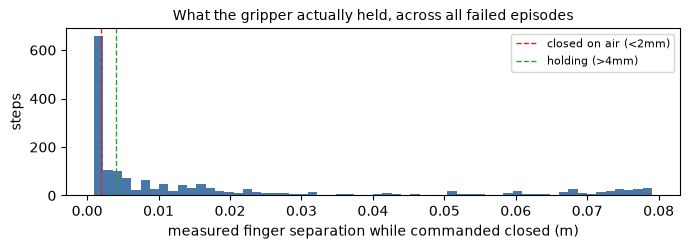

In [4]:
# Ground the thresholds in the data: measured finger separation while commanding "close".
closed_steps = fail_steps[fail_steps["gripper_action"] > 0]
if len(closed_steps):
    plt.figure(figsize=(7, 2.6))
    plt.hist(closed_steps["gripper_state"], bins=60, color="#4878a8")
    plt.axvline(AIR_MM, color="#d62728", ls="--", lw=1, label=f"closed on air (<{AIR_MM*1000:.0f}mm)")
    plt.axvline(HOLD_MM, color="#2ca02c", ls="--", lw=1, label=f"holding (>{HOLD_MM*1000:.0f}mm)")
    plt.xlabel("measured finger separation while commanded closed (m)")
    plt.ylabel("steps")
    plt.legend(fontsize=8)
    plt.title("What the gripper actually held, across all failed episodes", fontsize=10)
    plt.tight_layout()

## 3. Name the failure modes

A tiny rule set over those features labels every failure. The vocabulary is the schema's
`TERMINAL_FAILURE_LABELS` — the notebook writes what the rollout left as `unlabeled`.

In [5]:
def label_failure(f: pd.Series) -> str:
    if f.close_cycles >= 2 and f.ever_held:
        return "re_grasp"           # grasp -> lose -> re-attempt (the fumble loop)
    if not f.ever_held:
        return "no_grasp"           # never got the object between the fingers
    if f.max_lift < 0.02:
        return "grasp_no_lift"      # held it but never lifted
    if f.close_cycles == 1:
        return "missed_target"      # held + lifted + still failed => wrong placement
    return "timeout"


if len(feats):
    feats["failure_mode"] = feats.apply(label_failure, axis=1)
    mix = feats.groupby(["policy_type", "failure_mode"]).size().unstack(fill_value=0)
    print(mix.to_string())

failure_mode  no_grasp  re_grasp
policy_type                     
openvla              1        15
vla_jepa             0         1


## 4. The hero: watch a re-grasp loop without watching anything

The annotated per-step trace of the most fumble-prone failure — commanded close/open
transitions against the *measured* finger separation, with end-effector height overlaid.
Every marker is a grasp attempt; separations collapsing to ~1 mm are the gripper closing on
air.

video for this episode: /outputs/videos/openvla/libero_spatial__1__0__7__fail.mp4


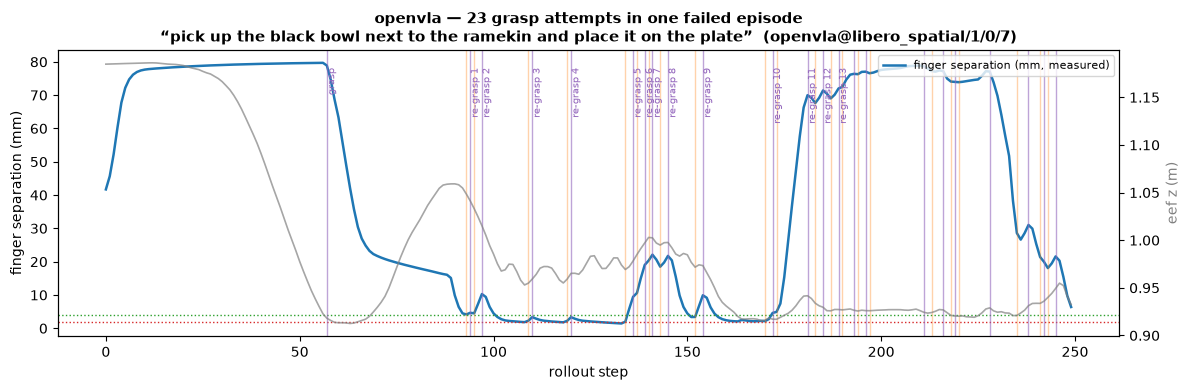

In [6]:
if len(feats):
    # Showcase the policy whose failures dominate the comparison (most failures), falling back
    # to the global fumble champion.
    pool = feats[feats["failure_mode"] == "re_grasp"] if (feats["failure_mode"] == "re_grasp").any() else feats
    top_policy = feats["policy_type"].value_counts().idxmax()
    if (pool["policy_type"] == top_policy).any():
        pool = pool[pool["policy_type"] == top_policy]
    hero_id = pool.sort_values("close_cycles").index[-1]
    hero = fail_steps[fail_steps["uid"] == hero_id].sort_values("step_idx")
    ga = hero["gripper_action"].to_numpy(dtype=float)
    gs = hero["gripper_state"].to_numpy(dtype=float) * 1000  # mm
    z = np.stack(hero["eef_pos"].to_numpy())[:, 2]
    t = np.arange(len(ga))
    closes = np.flatnonzero((ga[1:] > 0) & (ga[:-1] <= 0)) + 1
    opens = np.flatnonzero((ga[1:] < 0) & (ga[:-1] >= 0)) + 1

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(t, gs, lw=1.8, color="#1f77b4", label="finger separation (mm, measured)")
    ax.axhline(HOLD_MM * 1000, color="#2ca02c", ls=":", lw=1)
    ax.axhline(AIR_MM * 1000, color="#d62728", ls=":", lw=1)
    for i, c in enumerate(closes):
        ax.axvline(c, color="#9467bd", alpha=0.6, lw=1)
        if i < 14:
            ax.annotate("grasp" if i == 0 else f"re-grasp {i}", (c, gs.max() * 0.98),
                        rotation=90, fontsize=7, color="#9467bd", va="top")
    for o in opens:
        ax.axvline(o, color="#ff7f0e", alpha=0.35, lw=1)
    ax2 = ax.twinx()
    ax2.plot(t, z, lw=1.2, color="gray", alpha=0.7, label="eef height (m)")
    ax2.set_ylabel("eef z (m)", color="gray")
    ax.set_xlabel("rollout step")
    ax.set_ylabel("finger separation (mm)")
    pol = feats.loc[hero_id, "policy_type"]
    ax.set_title(f"{pol} — {int(feats.loc[hero_id, 'close_cycles'])} grasp attempts in one failed episode\n"
                 f"“{feats.loc[hero_id, 'instruction'][:80]}”  ({hero_id})",
                 fontsize=11, fontweight="bold")
    ax.legend(loc="upper right", fontsize=8)
    fig.tight_layout()
    print("video for this episode:", feats.loc[hero_id, "video_path"])

## 5. The payoff: the two policies fail *differently*

The success-rate gap says one model is better. The failure mix says **what to fix**.

openvla fails 16x more often than vla_jepa (16% vs 1%) — and 15 of its 16 failures are re-grasp fumble loops.


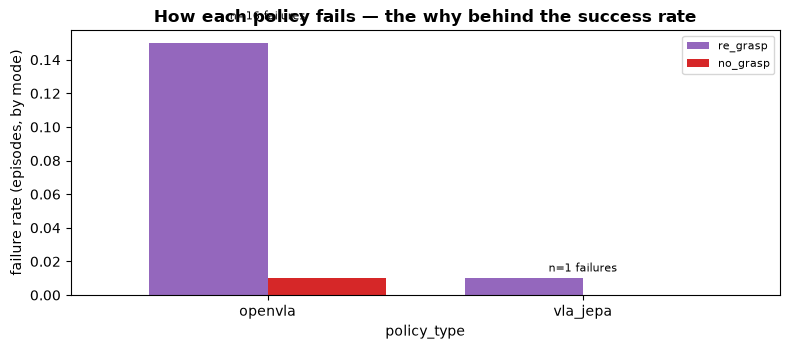

In [7]:
if len(feats):
    counts = (feats.groupby("policy_type")["failure_mode"]
                   .value_counts().unstack(fill_value=0)
                   .reindex(episodes["policy_type"].unique(), fill_value=0))
    order = [c for c in ["re_grasp", "no_grasp", "grasp_no_lift", "missed_target", "timeout"]
             if c in counts.columns]
    n_eps = episodes.groupby("policy_type").size()
    rate = counts.div(n_eps, axis=0)          # failures per episode, by mode — comparable scale
    ax = rate[order].plot.bar(figsize=(8, 3.6), width=0.75,
                              color=["#9467bd", "#d62728", "#ff7f0e", "#1f77b4", "gray"])
    ax.set_ylabel("failure rate (episodes, by mode)")
    ax.set_title("How each policy fails — the why behind the success rate", fontweight="bold")
    for i, p in enumerate(rate.index):
        ax.text(i, rate.loc[p, order].sum() + 0.004, f"n={int(counts.loc[p].sum())} failures",
                ha="center", fontsize=8)
    ax.legend(fontsize=8, title=None)
    plt.xticks(rotation=0)
    plt.tight_layout()

    fr = 1.0 - episodes.groupby("policy_type")["success"].mean()
    lo, hi = fr.idxmin(), fr.idxmax()
    line = (f"{hi} fails {fr[hi] / max(fr[lo], 1e-9):.0f}x more often than {lo} "
            f"({fr[hi]:.0%} vs {fr[lo]:.0%})")
    if "re_grasp" in counts.columns and counts.loc[hi].sum() >= 5:
        line += (f" — and {int(counts.loc[hi, 're_grasp'])} of its {int(counts.loc[hi].sum())} "
                 f"failures are re-grasp fumble loops.")
    print(line)

## Reproduce this

```bash
modal run harness/rollout/modal_vla_jepa_app.py --suites libero_spatial --episodes 10 --seed 7
modal run harness/rollout/modal_app.py --policy-type openvla --suites libero_spatial --episodes 10 --seed 7
modal volume get daft-model-outputs rollouts/ data/rollouts/
```

Protocol notes: `libero_spatial`, all 10 tasks, deterministic init states 0–9, seed 7 — an
honest 10-trial-per-task subset of the canonical 50-trial protocol (constants and the full
evaluation grammar: [`docs/EVAL_PATTERNS.md`](../docs/EVAL_PATTERNS.md)). Thresholds
(`HOLD_MM`, `AIR_MM`) were read off real episodes in §2's histogram — recheck them if your
gripper differs. Per-episode mp4s sit next to the parquet (`video_path` column) when you do
want to *see* the fumble the query found.

In [8]:
# Machine-readable summary (used by the README/blog):
if len(feats):
    print(json.dumps({
        "episodes": int(len(episodes)),
        "success_rate": {k: round(float(v), 3) for k, v in
                         episodes.groupby("policy_type")["success"].mean().items()},
        "failures": int(len(feats)),
        "failure_mix": {p: dict(Counter(g["failure_mode"]))
                        for p, g in feats.groupby("policy_type")},
    }, indent=2))

{
  "episodes": 200,
  "success_rate": {
    "openvla": 0.84,
    "vla_jepa": 0.99
  },
  "failures": 17,
  "failure_mix": {
    "openvla": {
      "re_grasp": 15,
      "no_grasp": 1
    },
    "vla_jepa": {
      "re_grasp": 1
    }
  }
}
